# Content with notebooks

You can also create content with Jupyter Notebooks. This means that you can include
code blocks and their outputs in your book.

## Markdown + notebooks

As it is markdown, you can embed images, HTML, etc into your posts!

![](logo.jpg)

You can also $add_{math}$ and

$$
math^{blocks}
$$

or

$$
\begin{aligned}
\mbox{mean} la_{tex} \\ \\
math blocks
\end{aligned}
$$

But make sure you \$Escape \$your \$dollar signs \$you want to keep!

## MyST markdown

MyST markdown works in Jupyter Notebooks as well. For more information about MyST markdown, check
out [the MyST guide in Jupyter Book](https://jupyterbook.org/content/myst.html),
or see [the MyST markdown documentation](https://myst-parser.readthedocs.io/en/latest/).

## Code blocks and outputs

Jupyter Book will also embed your code blocks and output in your book.
For example, here's some sample Matplotlib code:

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import numpy as np



In [2]:
df_taxi = pd.read_csv(r"C:\Users\PC\Desktop\data trabajo final\archive\yellow_tripdata_2019-01.csv")


In [9]:
df_taxi.shape

(7667792, 18)

In [10]:
def process_taxi_data(df_taxi):
    taxi = df_taxi[['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'PULocationID',
                   'DOLocationID','passenger_count', 'trip_distance','fare_amount','total_amount', 'payment_type', 'tolls_amount']].copy()
    # Renaming Columns
    new_names = {'tpep_pickup_datetime': 'PickUpDate', 'tpep_dropoff_datetime':'DropOffDate', 'passenger_count': 'Passengers', 
                 'trip_distance':'Distance'}
    taxi = taxi.rename(columns=new_names)
    # Correct Format in Date Columns
    taxi['PickUpDate'] = pd.to_datetime(taxi['PickUpDate'], format='%Y-%m-%d %H:%M:%S')
    taxi['DropOffDate'] = pd.to_datetime(taxi['DropOffDate'], format='%Y-%m-%d %H:%M:%S')
    # Create Columns for Date Analysis
    taxi['PickUpYear'] = taxi['PickUpDate'].dt.year
    taxi['PickUpMonth'] = taxi['PickUpDate'].dt.month
    taxi['PickUpWeek'] = taxi['PickUpDate'].dt.isocalendar().week
    taxi['PickUpDay'] = taxi['PickUpDate'].dt.day
    taxi['PickUpHour'] = taxi['PickUpDate'].dt.hour
    taxi['PickUpDayWeek'] = taxi['PickUpDate'].dt.dayofweek + 1 
    # Duration Column
    taxi['Duration'] = taxi['DropOffDate'] - taxi['PickUpDate']
    # Total Amount Column
    taxi['total_amount'] = taxi['total_amount'].abs()
    # Drop Date Columns
    taxi = taxi.drop(labels=['PickUpDate', 'DropOffDate'], axis=1)
    return taxi
taxi_df = process_taxi_data(df_taxi)

taxi_df = process_taxi_data(df_taxi)
taxi_df = taxi_df[['PULocationID', 'DOLocationID', 'Passengers', 'Distance', 'fare_amount', 'total_amount', 'PickUpYear', 'PickUpMonth', 'PickUpWeek', 'PickUpDay', 'PickUpHour', 'PickUpDayWeek','payment_type', 'tolls_amount', 'Duration' ]]
taxi_df.head()



,PULocationID,DOLocationID,Passengers,Distance,fare_amount,total_amount,PickUpYear,PickUpMonth,PickUpWeek,PickUpDay,PickUpHour,PickUpDayWeek,payment_type,tolls_amount,Duration
0,151,239,1,1.5,7.0,9.95,2019,1,1,1,0,2,1,0.0,0 days 00:06:40
1,239,246,1,2.6,14.0,16.30,2019,1,1,1,0,2,1,0.0,0 days 00:19:12
2,236,236,3,0.0,4.5,5.80,2018,12,51,21,13,5,1,0.0,0 days 00:04:10
3,193,193,5,0.0,3.5,7.55,2018,11,48,28,15,3,2,0.0,0 days 00:03:20
4,193,193,5,0.0,52.0,55.55,2018,11,48,28,15,3,2,0.0,0 days 00:01:36


In [11]:
negative_durations = taxi_df[taxi_df['Duration'] < pd.Timedelta(0)]
negative_durations

,PULocationID,DOLocationID,Passengers,Distance,fare_amount,total_amount,PickUpYear,PickUpMonth,PickUpWeek,PickUpDay,PickUpHour,PickUpDayWeek,payment_type,tolls_amount,Duration
1203127,100,79,1,3.3,16.00,16.80,2019,1,1,6,15,7,2,0.00,-59 days +11:19:30
2976251,164,145,3,7.6,29.50,36.06,2019,1,2,13,15,7,2,5.76,-20 days +16:22:16
4741726,186,162,1,1.9,15.50,19.55,2019,1,3,20,15,7,1,0.00,-2 days +00:41:46
5175736,265,265,1,0.0,3.52,3.77,2019,1,4,22,16,2,2,0.00,-1 days +23:59:00


In [14]:
taxi_df = taxi_df[taxi_df['Duration'] >= pd.Timedelta(0)]
taxi_df['Duration'].describe()

count                      7667788
mean     0 days 00:16:29.773001679
std      0 days 01:15:15.920851954
min                0 days 00:00:00
25%                0 days 00:06:06
50%                0 days 00:10:09
75%                0 days 00:16:34
max               30 days 07:28:01
Name: Duration, dtype: object

# **eliminar datos atípidos**

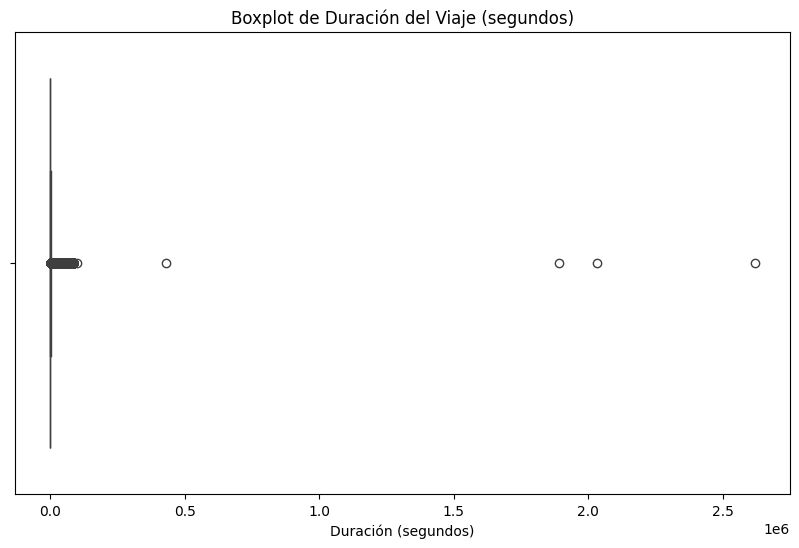

In [15]:
# Convertir la columna 'Duration' a números (segundos) para poder hacer un boxplot
taxi_df['Duration_seconds'] = taxi_df['Duration'].dt.total_seconds()

# Ahora puedes hacer un boxplot de 'Duration_seconds'
plt.figure(figsize=(10, 6))
sns.boxplot(x=taxi_df['Duration_seconds'])
plt.title('Boxplot de Duración del Viaje (segundos)')
plt.xlabel('Duración (segundos)')
plt.show()

In [17]:
# Convertir la columna 'Duration' a minutos
taxi_df['Duration_minutes'] = taxi_df['Duration'].dt.total_seconds() / 60

# Crear rangos de minutos
bins = [0, 11, 21, 31, 41, 51, 61, 71, 81, 91, 101, float('inf')]
labels = ['0-11', '11-21', '21-31', '31-41', '41-51', '51-61', '61-71', '71-81', '81-91', '91-101', '101+']

# Agrupar por rangos de minutos y contar las carreras
taxi_df['Duration_range'] = pd.cut(taxi_df['Duration_minutes'], bins=bins, labels=labels, include_lowest=True)
race_count_by_range = taxi_df.groupby('Duration_range')['Duration'].count()

race_count_by_range

C:\Users\PC\AppData\Local\Temp\ipykernel_21788\3245737099.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  race_count_by_range = taxi_df.groupby('Duration_range')['Duration'].count()


Duration_range
0-11      4171029
11-21     2299490
21-31      748375
31-41      260636
41-51      100123
51-61       40545
61-71       16582
71-81        6262
81-91        2153
91-101        790
101+        21803
Name: Duration, dtype: int64

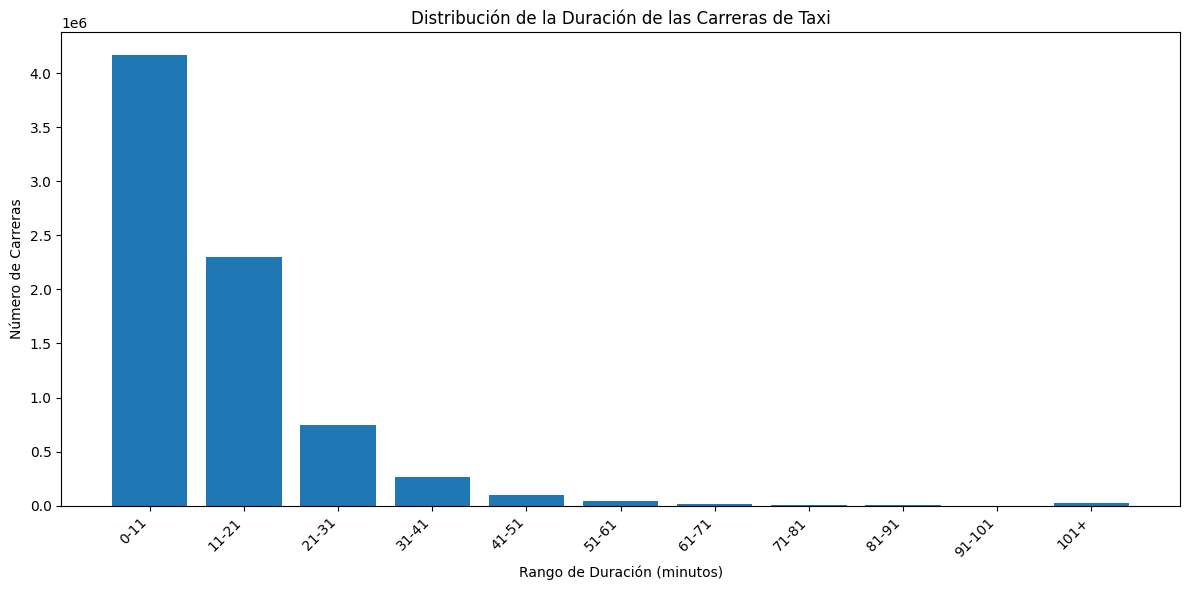

In [18]:
# Crear el gráfico de barras
plt.figure(figsize=(12, 6))  # Ajustar el tamaño del gráfico
plt.bar(race_count_by_range.index, race_count_by_range.values)

# Etiquetas y título del gráfico
plt.xlabel('Rango de Duración (minutos)')
plt.ylabel('Número de Carreras')
plt.title('Distribución de la Duración de las Carreras de Taxi')

# Rotar las etiquetas del eje x para una mejor legibilidad (opcional)
plt.xticks(rotation=45, ha='right')

# Mostrar el gráfico
plt.tight_layout()
plt.show()

In [19]:
# Check for NaN values in the DataFrame
nan_counts = taxi_df.isna().sum()

# Print the counts of NaN values for each column
print(nan_counts)

# Optionally, you can also check if there are any NaN values in the entire DataFrame
has_nan = taxi_df.isnull().values.any()
print(f"\nDoes the DataFrame contain NaN values? {has_nan}")

PULocationID        0
DOLocationID        0
Passengers          0
Distance            0
fare_amount         0
total_amount        0
PickUpYear          0
PickUpMonth         0
PickUpWeek          0
PickUpDay           0
PickUpHour          0
PickUpDayWeek       0
payment_type        0
tolls_amount        0
Duration            0
Duration_seconds    0
DurationSeconds     0
DurationMinutes     0
Duration_minutes    0
Duration_range      0
dtype: int64

Does the DataFrame contain NaN values? False


In [20]:

duplicate_rows = taxi_df[taxi_df.duplicated()]
num_duplicates = len(duplicate_rows)
print(f"Número de filas duplicadas: {num_duplicates}")

Número de filas duplicadas: 967


In [21]:
# Eliminar filas con valores NaN
taxi_df = taxi_df.dropna()

# Eliminar filas duplicadas
taxi_df = taxi_df.drop_duplicates()

# Verificar si se eliminaron los valores NaN y las filas duplicadas
nan_counts = taxi_df.isna().sum()
print(nan_counts)

duplicate_rows = taxi_df[taxi_df.duplicated()]
num_duplicates = len(duplicate_rows)
print(f"Número de filas duplicadas: {num_duplicates}")

PULocationID        0
DOLocationID        0
Passengers          0
Distance            0
fare_amount         0
total_amount        0
PickUpYear          0
PickUpMonth         0
PickUpWeek          0
PickUpDay           0
PickUpHour          0
PickUpDayWeek       0
payment_type        0
tolls_amount        0
Duration            0
Duration_seconds    0
DurationSeconds     0
DurationMinutes     0
Duration_minutes    0
Duration_range      0
dtype: int64
Número de filas duplicadas: 0


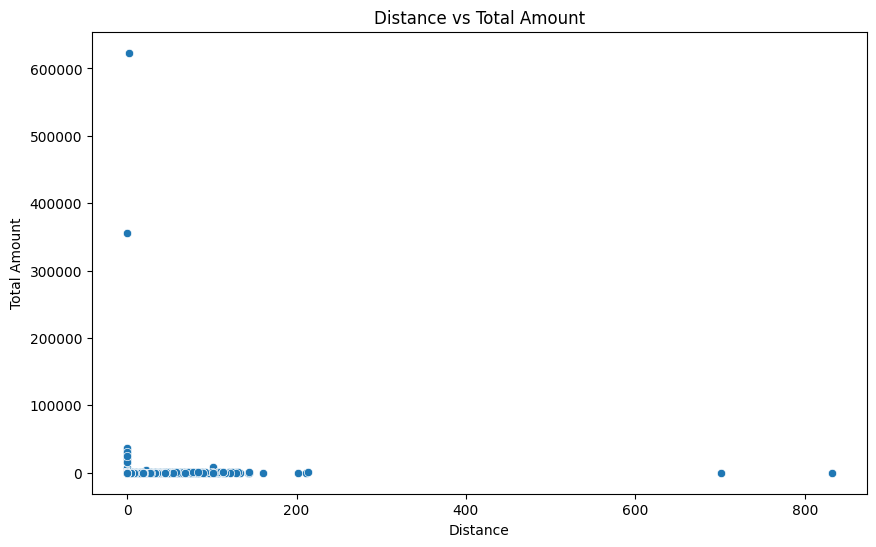

In [12]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Distance', y='total_amount', data=taxi_df)
plt.title('Distance vs Total Amount')
plt.xlabel('Distance')
plt.ylabel('Total Amount')
plt.show()


There is a lot more that you can do with outputs (such as including interactive outputs)
with your book. For more information about this, see [the Jupyter Book documentation](https://jupyterbook.org)